<table style="border: none; border-collapse: collapse;">
    <tr>
        <td style="width: 22%; vertical-align: middle; padding-right: 10px;">
            <img src="https://upload.wikimedia.org/wikipedia/commons/d/df/Logo_UNIR.png" width="250">
        </td>
        <td style="width: 2px; text-align: center;">
            <font color="#3facc9" size="7">|</font><br>
            <font color="#3facc9" size="7">|</font>
        </td>
        <td>
            <p style="font-variant: small-caps;"><font color="#3facc9" size="5">
                <b>Maestría en Computación Cuántica</b>
            </font> </p>
            <p style="font-variant: small-caps;"><font color="#3facc9" size="4">
                Información Cuántica &bull; Actividad 3. Codificación de circuitos para la corrección cuántica de errores
            </font></p>
            <p style="font-style: oblique;"><font color="#3facc9" size="3">
                Andrés Merino &bull; Junio 2026
            </font></p>
        </td>  
    </tr>
</table>

---
## <font color='3facc9'> Librerías necesarias </font>

Importamos las librerías necesarias:

* `numpy`: operaciones numéricas y álgebra lineal.

* `pandas`: construcción de tablas de resultados.

* `IPython.display`: herramientas de visualización en notebooks.

* `qiskit`: librería para computación cuántica.

  * `QuantumCircuit`, `QuantumRegister`, `ClassicalRegister`: construcción de circuitos cuánticos.

* `qiskit.quantum_info`: herramientas de análisis de estados cuánticos.

  * `Statevector`: representación de estados cuánticos mediante vectores de amplitudes.

* `qiskit_aer`: simuladores de circuitos cuánticos.

  * `AerSimulator`: simulador para ejecutar circuitos cuánticos.

In [1]:
import numpy as np
import pandas as pd
from IPython.display import display, Markdown
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.quantum_info import Statevector, Pauli, SparsePauliOp
from qiskit_aer import AerSimulator

---
## <font color='3facc9'> Pautas de elaboración </font>

Siguiendo el algoritmo de cinco cúbits [[5,1,3]], se desarrolla un circuito cuántico utilizando Qiskit que lleva a cabo el cifrado, descifrado y análisis del síndrome. Se prueba el correcto funcionamiento del circuito y se obtiene la tabla de síndrome que recoge su valor para cada tipo de error (volteo de bit $X$, volteo de fase $Z$ y combinado $Y$) en cada cúbit del circuito.

El código es modular: cada fase del proceso (preparación del estado codificado, inyección de error, medición del síndrome, corrección y verificación) está encapsulada en una función independiente.

---
## <font color='3facc9'> Teoría: Código de 5 Cúbits [[5,1,3]] </font>

El código cuántico perfecto de 5 cúbits codifica 1 cúbit lógico en 5 cúbits físicos y puede corregir cualquier error de Pauli de un único cúbit. Es el código cuántico con menor número de cúbits que logra esta capacidad.

### Generadores estabilizadores

El código está definido por 4 operadores estabilizadores (operadores de Pauli sobre los 5 cúbits físicos $q_0 q_1 q_2 q_3 q_4$):

| Estabilizador | $q_0$ | $q_1$ | $q_2$ | $q_3$ | $q_4$ |
|:---:|:---:|:---:|:---:|:---:|:---:|
| $g_1$ | $X$ | $Z$ | $Z$ | $X$ | $I$ |
| $g_2$ | $I$ | $X$ | $Z$ | $Z$ | $X$ |
| $g_3$ | $X$ | $I$ | $X$ | $Z$ | $Z$ |
| $g_4$ | $Z$ | $X$ | $I$ | $X$ | $Z$ |

Un estado pertenece al espacio de código si y solo si es autovector $+1$ de los cuatro estabilizadores.

### Operadores lógicos

$$\bar{X} = X_0 X_1 X_2 X_3 X_4, \qquad \bar{Z} = Z_0 Z_1 Z_2 Z_3 Z_4$$

### Estados lógicos codificados

Los cúbits lógicos son la superposición de 16 estados de la base computacional, obtenida aplicando los 16 elementos del grupo estabilizador sobre $|00000\rangle$:

$$|0_L\rangle = \frac{1}{4}\bigl(|00000\rangle + |10010\rangle + |01001\rangle + |10100\rangle + |01010\rangle + |00101\rangle$$
$$- |11011\rangle - |00110\rangle - |11000\rangle - |11101\rangle - |00011\rangle - |11110\rangle - |01111\rangle - |10001\rangle - |01100\rangle - |10111\rangle\bigr)$$

$$|1_L\rangle = \bar{X}|0_L\rangle$$

### Medición del síndrome

Para medir el estabilizador $g_i$ se utiliza un cúbit ancilla:

1. Inicializar ancilla en $|+\rangle = H|0\rangle$
2. Aplicar $CX$ (ancilla→dato) para cada $X$ en $g_i$, y $CZ$ para cada $Z$
3. Aplicar $H$ al ancilla
4. Medir: resultado $0$ si el estado es autovector $+1$ de $g_i$; $1$ si es $-1$

### Tabla teórica de síndromes

El bit $s_i$ indica anticonmutación con $g_i$. Los 15 errores de un cúbit producen síndromes únicos:

| Error | $s_1 s_2 s_3 s_4$ | Error | $s_1 s_2 s_3 s_4$ | Error | $s_1 s_2 s_3 s_4$ |
|:---:|:---:|:---:|:---:|:---:|:---:|
| Ninguno | `0000` | $X_0$ | `0001` | $Z_0$ | `1010` |
| $Y_0$ | `1011` | $X_1$ | `1000` | $Z_1$ | `0101` |
| $Y_1$ | `1101` | $X_2$ | `1100` | $Z_2$ | `0010` |
| $Y_2$ | `1110` | $X_3$ | `0110` | $Z_3$ | `1001` |
| $Y_3$ | `1111` | $X_4$ | `0011` | $Z_4$ | `0100` |
| $Y_4$ | `0111` | | | | |

---
## <font color='3facc9'> Implementación </font>

### Preparación de los estados lógicos

Construimos $|0_L\rangle$ directamente a partir de las amplitudes teóricas. Los 16 estados con amplitud $+1/4$ y los 10 con amplitud $-1/4$ se obtienen aplicando los 16 elementos del grupo estabilizador sobre $|00000\rangle$. El estado $|1_L\rangle$ se obtiene aplicando $\bar{X} = X^{\otimes 5}$, que voltea todos los bits.

In [2]:
# Índices con amplitud +1 en |0_L>
_positivos = [0b00000, 0b10010, 0b01001, 0b10100, 0b01010, 0b00101]
# Índices con amplitud -1 en |0_L>
_negativos = [0b11011, 0b00110, 0b11000, 0b11101, 0b00011,
              0b11110, 0b01111, 0b10001, 0b01100, 0b10111]

sv_0L = np.zeros(32, dtype=complex)
for idx in _positivos:
    sv_0L[idx] = +1.0
for idx in _negativos:
    sv_0L[idx] = -1.0
sv_0L /= np.linalg.norm(sv_0L)

# |1_L> = X_L |0_L>: voltear todos los bits de cada índice
sv_1L = np.zeros(32, dtype=complex)
for i, amp in enumerate(sv_0L):
    j = (~i) & 0b11111
    sv_1L[j] = amp

print("Norma |0_L>:", round(np.linalg.norm(sv_0L), 10))
print("Norma |1_L>:", round(np.linalg.norm(sv_1L), 10))
print("Ortogonalidad <0_L|1_L>:", round(abs(sv_0L.conj() @ sv_1L), 10))

Norma |0_L>: 1.0
Norma |1_L>: 1.0
Ortogonalidad <0_L|1_L>: 0.0


Visualizamos el estado $|0_L\rangle$ en notación de Dirac:

In [3]:
display(Markdown("**Estado lógico $|0_L\\rangle$**"))
display(Statevector(sv_0L).draw("latex"))

display(Markdown("**Estado lógico $|1_L\\rangle$**"))
display(Statevector(sv_1L).draw("latex"))

**Estado lógico $|0_L\rangle$**

<IPython.core.display.Latex object>

**Estado lógico $|1_L\rangle$**

<IPython.core.display.Latex object>

### Verificación del espacio de código

Comprobamos que $|0_L\rangle$ y $|1_L\rangle$ son autovectores $+1$ de los cuatro estabilizadores. Usamos `Statevector.evolve` para aplicar cada estabilizador como un operador de Pauli y verificamos que el estado no cambia.

In [4]:
# Estabilizadores en notación de Qiskit
NOMBRES_ESTABILIZADORES = ['g1=XZZXI', 'g2=IXZZX', 'g3=XIXZZ', 'g4=ZXIXZ']

ESTABILIZADORES_STR = ['IXZZX', 'XZZXI', 'ZZXIX', 'ZXIXZ']

ESTABILIZADORES_PAULI = [
    Pauli('IXZZX'),   # g1: q0=X, q1=Z, q2=Z, q3=X, q4=I
    Pauli('XZZXI'),   # g2: q0=I, q1=X, q2=Z, q3=Z, q4=X
    Pauli('ZZXIX'),   # g3: q0=X, q1=I, q2=X, q3=Z, q4=Z
    Pauli('ZXIXZ'),   # g4: q0=Z, q1=X, q2=I, q3=X, q4=Z
]

print("Verificación de estabilizadores para |0_L>:")
sv0 = Statevector(sv_0L)
for nombre, pauli in zip(NOMBRES_ESTABILIZADORES, ESTABILIZADORES_PAULI):
    sv_tras_estab = sv0.evolve(pauli)
    autovalor = sv_tras_estab.data @ sv_0L.conj()
    print(f"  {nombre}: autovalor = {autovalor.real:+.6f} (esperado +1)")

print("\nVerificación de estabilizadores para |1_L>:")
sv1 = Statevector(sv_1L)
for nombre, pauli in zip(NOMBRES_ESTABILIZADORES, ESTABILIZADORES_PAULI):
    sv_tras_estab = sv1.evolve(pauli)
    autovalor = sv_tras_estab.data @ sv_1L.conj()
    print(f"  {nombre}: autovalor = {autovalor.real:+.6f} (esperado +1)")

Verificación de estabilizadores para |0_L>:
  g1=XZZXI: autovalor = +1.000000 (esperado +1)
  g2=IXZZX: autovalor = +1.000000 (esperado +1)
  g3=XIXZZ: autovalor = +1.000000 (esperado +1)
  g4=ZXIXZ: autovalor = +1.000000 (esperado +1)

Verificación de estabilizadores para |1_L>:
  g1=XZZXI: autovalor = +1.000000 (esperado +1)
  g2=IXZZX: autovalor = +1.000000 (esperado +1)
  g3=XIXZZ: autovalor = +1.000000 (esperado +1)
  g4=ZXIXZ: autovalor = +1.000000 (esperado +1)


### Inyección de error

Función que aplica un error de Pauli ($X$, $Z$ o $Y$) en un cúbit específico del estado lógico.

In [5]:
def agregar_error(sv, qubit, tipo_error):
    """
    Aplica un error Pauli sobre el statevector dado.
    sv: numpy array de 32 amplitudes
    qubit: 0..4
    tipo_error: 'X', 'Z', 'Y' o None
    Devuelve el nuevo statevector.
    """
    if tipo_error is None:
        return sv.copy()
    qc = QuantumCircuit(5)
    if tipo_error == 'X':
        qc.x(qubit)
    elif tipo_error == 'Z':
        qc.z(qubit)
    elif tipo_error == 'Y':
        qc.y(qubit)
    return Statevector(sv).evolve(qc).data

### Circuito de medición del síndrome

Para cada estabilizador $g_i$ se utiliza un cúbit ancilla (qubits 5–8). El protocolo de medición es:

1. $H$ sobre la ancilla → $|+\rangle$
2. $CX$(ancilla, dato) para cada $X$ en el estabilizador
3. $CZ$(ancilla, dato) para cada $Z$ en el estabilizador
4. $H$ sobre la ancilla → medición en base $Z$

El resultado es $s_i = 0$ (estado en espacio $+1$) o $s_i = 1$ (error detectado).

In [ ]:
# Cada estabilizador como lista 
DEFINICION_ESTABILIZADORES = [
    [(0, 'X'), (1, 'Z'), (2, 'Z'), (3, 'X')],   # g1 = XZZXI
    [(1, 'X'), (2, 'Z'), (3, 'Z'), (4, 'X')],   # g2 = IXZZX
    [(0, 'X'), (2, 'X'), (3, 'Z'), (4, 'Z')],   # g3 = XIXZZ
    [(0, 'Z'), (1, 'X'), (3, 'X'), (4, 'Z')],   # g4 = ZXIXZ
]

def construir_circuito_sindrome(sv_con_error):
    """
    Construye el circuito de medición del síndrome.
    sv_con_error: statevector de 5 cúbits (con posible error)
    Devuelve el circuito de 9 cúbits (5 datos + 4 ancillas) listo para ejecutar.
    """
    datos = QuantumRegister(5, 'd')
    ancillas = QuantumRegister(4, 'a')
    cr_sindrome = ClassicalRegister(4, 's')

    qc = QuantumCircuit(datos, ancillas, cr_sindrome)

    # Inicializar los cúbits de datos con el estado 
    # Extendemos el statevector a 9 cúbits
    sv_extendido = np.zeros(512, dtype=complex)
    for i, amp in enumerate(sv_con_error):
        sv_extendido[i] = amp
    qc.initialize(sv_extendido)

    # Medición de cada estabilizador con su ancilla
    for i, estab in enumerate(DEFINICION_ESTABILIZADORES):
        a = 5 + i  # índice del cúbit ancilla
        qc.h(a)
        for (q, tipo) in estab:
            if tipo == 'X':
                qc.cx(a, q)
            elif tipo == 'Z':
                qc.cz(a, q)
        qc.h(a)
        qc.measure(a, cr_sindrome[i])

    return qc


def medir_sindrome(sv_con_error, shots=2000):
    """
    Ejecuta el circuito de síndrome y devuelve el resultado más frecuente.
    Devuelve el síndrome como string 's1s2s3s4'.
    """
    qc = construir_circuito_sindrome(sv_con_error)
    backend = AerSimulator()
    job = backend.run(qc, shots=shots)
    counts = job.result().get_counts()

    # El síndrome más frecuente (debería ser determinista)
    sindrome_qiskit = max(counts, key=counts.get)
    # Invertimos para obtener s1s2s3s4
    sindrome = sindrome_qiskit[::-1]
    return sindrome

Visualizamos el circuito de síndrome para un estado sin error:

**Circuito de medición del síndrome (9 cúbits: 5 datos + 4 ancillas)**

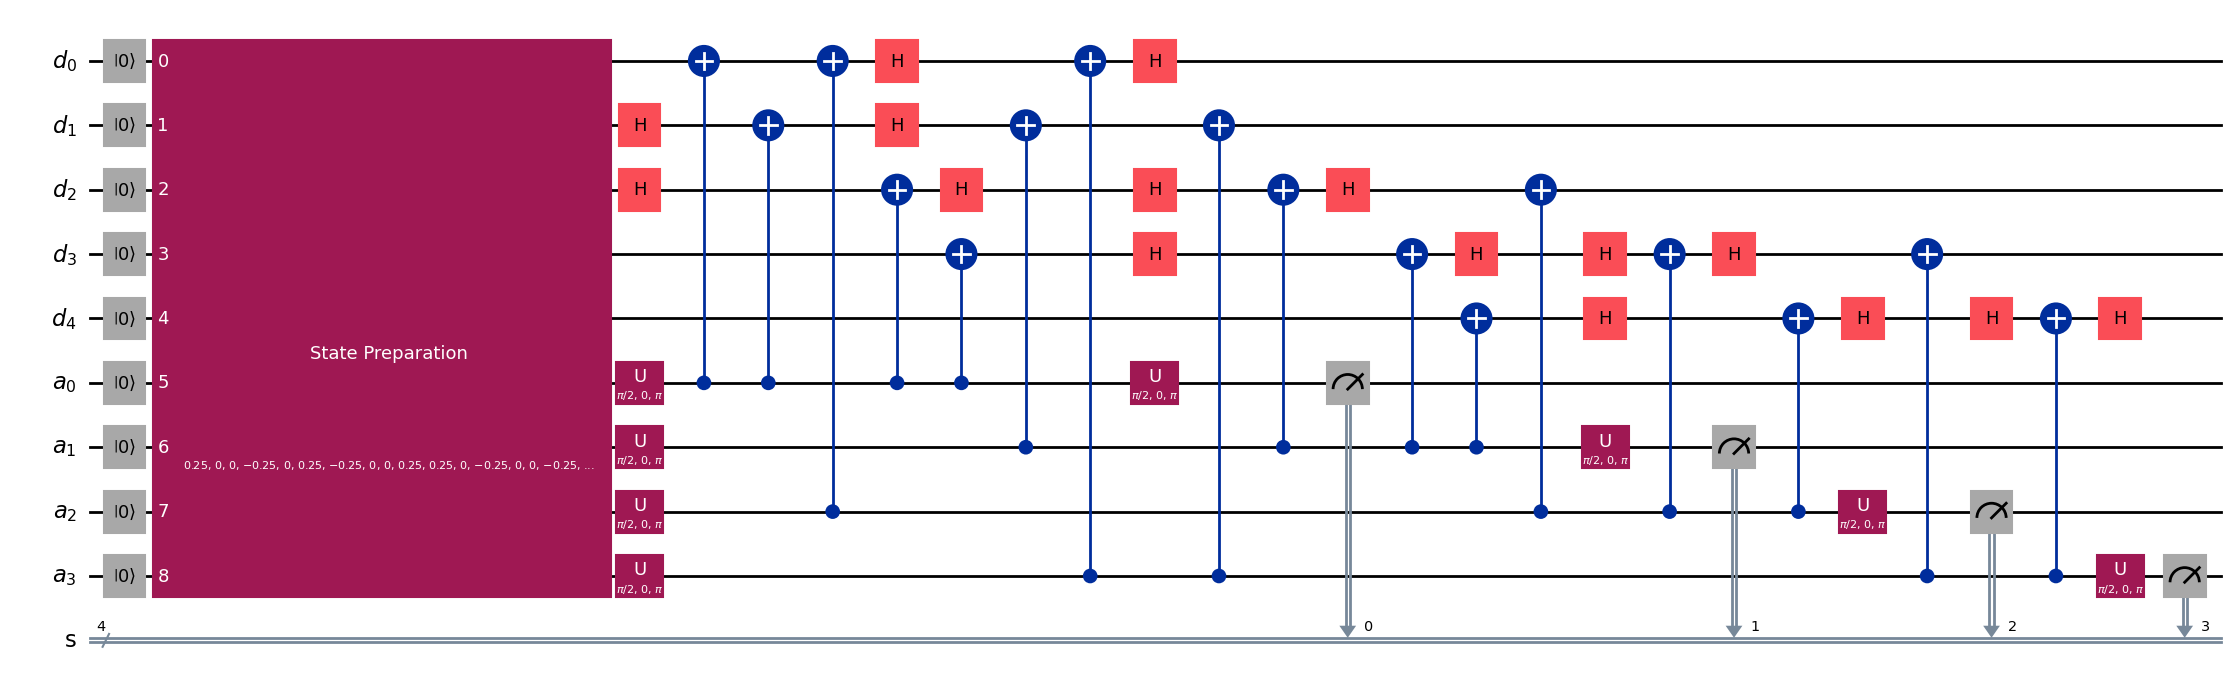

In [7]:
qc_ejemplo = construir_circuito_sindrome(sv_0L)
display(Markdown("**Circuito de medición del síndrome (9 cúbits: 5 datos + 4 ancillas)**"))
display(qc_ejemplo.decompose(reps=1).draw("mpl", fold=60))

### Tabla de corrección y función de corrección

La tabla mapea cada síndrome al error correspondiente. La corrección se aplica al mismo cúbit con el mismo operador de Pauli, dado que $X^2 = Z^2 = Y^2 = I$.

In [8]:
# Síndrome 's1s2s3s4' → (cúbit, tipo_error)
TABLA_CORRECCION = {
    '0000': None,
    # Errores X
    '0001': (0, 'X'), '1000': (1, 'X'), '1100': (2, 'X'),
    '0110': (3, 'X'), '0011': (4, 'X'),
    # Errores Z
    '1010': (0, 'Z'), '0101': (1, 'Z'), '0010': (2, 'Z'),
    '1001': (3, 'Z'), '0100': (4, 'Z'),
    # Errores Y
    '1011': (0, 'Y'), '1101': (1, 'Y'), '1110': (2, 'Y'),
    '1111': (3, 'Y'), '0111': (4, 'Y'),
}

def corregir_error(sv, sindrome):
    """
    Aplica la operación correctora al statevector según el síndrome.
    Devuelve el statevector corregido.
    """
    correccion = TABLA_CORRECCION.get(sindrome)
    if correccion is None:
        return sv.copy()
    qubit, tipo = correccion
    return agregar_error(sv, qubit, tipo)

---
## <font color='3facc9'> Resultados </font>

### Tabla de síndromes

Para cada uno de los 16 casos (sin error y los 15 errores de un cúbit), se prepara el estado $|0_L\rangle$, se inyecta el error, se ejecuta el circuito de síndrome con 2000 shots y se compara el resultado experimental con el valor teórico esperado.

In [9]:
SINDROME_ESPERADO = {
    (None, None): '0000',
    (0, 'X'): '0001', (1, 'X'): '1000', (2, 'X'): '1100',
    (3, 'X'): '0110', (4, 'X'): '0011',
    (0, 'Z'): '1010', (1, 'Z'): '0101', (2, 'Z'): '0010',
    (3, 'Z'): '1001', (4, 'Z'): '0100',
    (0, 'Y'): '1011', (1, 'Y'): '1101', (2, 'Y'): '1110',
    (3, 'Y'): '1111', (4, 'Y'): '0111',
}

LISTA_ERRORES = [
    (None, None),
    *[(q, 'X') for q in range(5)],
    *[(q, 'Z') for q in range(5)],
    *[(q, 'Y') for q in range(5)],
]

filas = []
for (qubit, tipo) in LISTA_ERRORES:
    nombre = 'Ninguno' if qubit is None else f'{tipo}_{qubit}'
    sv_error = agregar_error(sv_0L, qubit, tipo)
    sindrome = medir_sindrome(sv_error, shots=2000)
    esperado = SINDROME_ESPERADO[(qubit, tipo)]
    correcto = '✓' if sindrome == esperado else '✗'
    filas.append({
        'Error': nombre,
        'Síndrome obtenido': sindrome,
        'Síndrome esperado': esperado,
        'Correcto': correcto,
    })

df_sindrome = pd.DataFrame(filas)
display(Markdown("**Tabla de síndromes — Código [[5,1,3]]**"))
display(df_sindrome)

**Tabla de síndromes — Código [[5,1,3]]**

,Error,Síndrome obtenido,Síndrome esperado,Correcto
0,Ninguno,0000,0000,✓
1,X_0,0001,0001,✓
2,X_1,1000,1000,✓
3,X_2,1100,1100,✓
4,X_3,0110,0110,✓
5,X_4,0011,0011,✓
6,Z_0,1010,1010,✓
7,Z_1,0101,0101,✓
8,Z_2,0010,0010,✓
9,Z_3,1001,1001,✓


### Ciclo completo de corrección cuántica de errores

Demostramos el ciclo completo para casos representativos:

1. Preparar el estado lógico codificado
2. Introducir un error de Pauli
3. Medir el síndrome (con 2000 shots)
4. Identificar el error mediante la tabla de corrección
5. Aplicar la operación correctora
6. Verificar la fidelidad con el estado original

In [10]:
def ciclo_qec(sv_logico, qubit_error, tipo_error, shots=2000):
    """
    Ejecuta el ciclo completo de QEC y muestra los resultados.
    """
    nombre_estado = '$|0_L\\rangle$' if np.allclose(sv_logico, sv_0L) else '$|1_L\\rangle$'
    display(Markdown(
        f"#### Error ${tipo_error}_{{{qubit_error}}}$ sobre {nombre_estado}"
    ))

    # Paso 1: introducir el error
    sv_con_error = agregar_error(sv_logico, qubit_error, tipo_error)

    # Paso 2: medir el síndrome
    sindrome = medir_sindrome(sv_con_error, shots=shots)
    display(Markdown(f"- **Síndrome medido:** `{sindrome}`"))

    # Paso 3: identificar y aplicar corrección
    correccion = TABLA_CORRECCION.get(sindrome)
    if correccion:
        display(Markdown(
            f"- **Corrección:** operador ${correccion[1]}$ en $q_{{{correccion[0]}}}$"
        ))
    else:
        display(Markdown("- **Sin error detectado**"))

    sv_corregido = corregir_error(sv_con_error, sindrome)

    # Paso 4: verificar fidelidad
    fidelidad = abs(sv_logico.conj() @ sv_corregido) ** 2
    display(Markdown(f"- **Fidelidad con el estado original:** {fidelidad:.6f}"))
    resultado = "Estado recuperado correctamente ✓" if fidelidad > 0.999 else "Error en la recuperación ✗"
    display(Markdown(f"- **Resultado:** {resultado}"))

In [11]:
casos_demo = [
    (sv_0L, 0, 'X'),
    (sv_0L, 2, 'Z'),
    (sv_0L, 4, 'Y'),
    (sv_1L, 1, 'X'),
    (sv_1L, 3, 'Z'),
    (sv_1L, 0, 'Y'),
]

for sv, q, t in casos_demo:
    ciclo_qec(sv, q, t)
    display(Markdown("---"))

#### Error $X_{0}$ sobre $|0_L\rangle$

- **Síndrome medido:** `0001`

- **Corrección:** operador $X$ en $q_{0}$

- **Fidelidad con el estado original:** 1.000000

- **Resultado:** Estado recuperado correctamente ✓

...

- **Síndrome medido:** `1011`

- **Corrección:** operador $Y$ en $q_{0}$

- **Fidelidad con el estado original:** 1.000000

- **Resultado:** Estado recuperado correctamente ✓

---

### Verificación exhaustiva

Verificamos que el ciclo QEC recupera perfectamente el estado $|0_L\rangle$ para los 15 errores de un cúbit, calculando la fidelidad mediante comparación de vectores de estado.

In [12]:
filas_v = []
for (qubit, tipo) in LISTA_ERRORES:
    nombre = 'Ninguno' if qubit is None else f'{tipo}_{qubit}'
    sv_e = agregar_error(sv_0L, qubit, tipo)
    sindrome = medir_sindrome(sv_e, shots=2000)
    sv_c = corregir_error(sv_e, sindrome)
    fidelidad = abs(sv_0L.conj() @ sv_c) ** 2
    filas_v.append({
        'Error': nombre,
        'Síndrome': sindrome,
        'Fidelidad': f'{fidelidad:.6f}',
        'Recuperado': '✓' if fidelidad > 0.999 else '✗'
    })

df_v = pd.DataFrame(filas_v)
display(Markdown("**Verificación exhaustiva del ciclo QEC sobre $|0_L\\rangle$**"))
display(df_v)

**Verificación exhaustiva del ciclo QEC sobre $|0_L\rangle$**

,Error,Síndrome,Fidelidad,Recuperado
0,Ninguno,0000,1.000000,✓
1,X_0,0001,1.000000,✓
2,X_1,1000,1.000000,✓
3,X_2,1100,1.000000,✓
4,X_3,0110,1.000000,✓
5,X_4,0011,1.000000,✓
6,Z_0,1010,1.000000,✓
7,Z_1,0101,1.000000,✓
8,Z_2,0010,1.000000,✓
9,Z_3,1001,1.000000,✓
